# Airbnb Prices in European Cities

https://www.kaggle.com/datasets/thedevastator/airbnb-prices-in-european-cities

## Schema

Column name	Description
- realSum	The total price of the Airbnb listing. (Numeric)
- room_type	The type of room being offered (e.g. private, shared, etc.). (Categorical)
- room_shared	Whether the room is shared or not. (Boolean)
- room_private	Whether the room is private or not. (Boolean)
- person_capacity	The maximum number of people that can stay in the room. (Numeric)
- host_is_superhost	Whether the host is a superhost or not. (Boolean)
- multi	Whether the listing is for multiple rooms or not. (Boolean)
- biz	Whether the listing is for business purposes or not. (Boolean)
- cleanliness_rating	The cleanliness rating of the listing. (Numeric)
- guest_satisfaction_overall	The overall guest satisfaction rating of the listing. (Numeric)
- bedrooms	The number of bedrooms in the listing. (Numeric)
- dist	The distance from the city centre. (Numeric)
- metro_dist	The distance from the nearest metro station. (Numeric)
- lng	The longitude of the listing. (Numeric)
- lat	The latitude of the listing. (Numeric)

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Directory path
cwd = os.getcwd()
#directory = "aex_data/"
print(type(cwd))
datasets_directory ="\\".join(cwd.split("\\")[:-1])
# List files and directories in the directory
print(datasets_directory)
files_and_directories = os.listdir(cwd)
dataset = os.listdir(datasets_directory)
# Print the list
print("Files and directories in", cwd, ":")
for item in files_and_directories:
    print(item)

print("Files and directories in", datasets_directory, ":")
for item in dataset:
    print(item)

<class 'str'>
C:\Users\Asus\Desktop\PersonalProject\Kaggle\AirBnB
Files and directories in C:\Users\Asus\Desktop\PersonalProject\Kaggle\AirBnB\kaggle_airbnb_insights :
.git
.ipynb_checkpoints
Kaggle_airbnb_insights.ipynb
README.md
Files and directories in C:\Users\Asus\Desktop\PersonalProject\Kaggle\AirBnB :
amsterdam_weekdays.csv
amsterdam_weekends.csv
athens_weekdays.csv
athens_weekends.csv
barcelona_weekdays.csv
barcelona_weekends.csv
berlin_weekdays.csv
berlin_weekends.csv
budapest_weekdays.csv
budapest_weekends.csv
kaggle_airbnb_insights
lisbon_weekdays.csv
lisbon_weekends.csv
london_weekdays.csv
london_weekends.csv
paris_weekdays.csv
paris_weekends.csv
rome_weekdays.csv
rome_weekends.csv
vienna_weekdays.csv
vienna_weekends.csv


In [5]:
designated_stock_path = datasets_directory +"\\" +"amsterdam_weekdays.csv"
df_AMS_weekdays = pd.read_csv(designated_stock_path)

In [6]:
df_AMS_weekdays.head()

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
0,0,194.033698,Private room,False,True,2.0,False,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473,4.90569,52.41772
1,1,344.245776,Private room,False,True,4.0,False,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928,4.90005,52.37432
2,2,264.101422,Private room,False,True,2.0,False,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700,4.97512,52.36103
3,3,433.529398,Private room,False,True,4.0,False,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565,4.89417,52.37663
4,4,485.552926,Private room,False,True,2.0,True,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677,4.90051,52.37508


In [7]:
# Remove index column
df_AMS_weekdays_drop1 = df_AMS_weekdays.drop(columns=["Unnamed: 0"])

In [8]:
df_AMS_weekdays_drop1.tail()

,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
1098,2486.115342,Entire home/apt,False,False,2.0,False,0,0,10.0,100.0,1,2.375833,1.436054,181.198355,9.594573,225.304203,15.699521,4.85869,52.37677
1099,233.637194,Private room,False,True,2.0,False,1,0,10.0,90.0,1,4.719736,0.322263,108.024880,5.719989,134.775277,9.391335,4.83611,52.34910
1100,317.062311,Private room,False,True,2.0,False,1,0,10.0,92.0,1,0.598355,0.751993,440.476515,23.323524,625.947562,43.616927,4.88897,52.37798
1101,1812.855904,Entire home/apt,False,False,4.0,False,0,0,8.0,84.0,5,1.943020,0.388532,257.948105,13.658524,336.589237,23.454022,4.90688,52.35794
1102,258.008577,Shared room,True,False,2.0,False,0,0,8.0,90.0,1,0.280204,0.516217,533.962653,28.273677,807.492307,56.267226,4.89295,52.37575


In [9]:
df_AMS_weekdays_drop1.describe()

,realSum,person_capacity,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
count,1103.000000,1103.000000,1103.00000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000
mean,545.020526,2.792384,0.30825,0.115141,9.461469,94.362647,1.282865,2.841621,1.089439,271.009899,14.350154,341.541187,23.799081,4.891158,52.364858
std,416.974314,1.044151,0.46198,0.319336,0.798201,6.089691,0.740178,2.123245,0.836546,197.046890,10.433764,236.611077,16.487400,0.038882,0.019467
min,128.887118,2.000000,0.00000,0.000000,4.000000,20.000000,0.000000,0.015059,0.036530,40.931415,2.167346,50.877318,3.545205,4.775500,52.291100
25%,309.797764,2.000000,0.00000,0.000000,9.000000,92.000000,1.000000,1.302058,0.462983,127.909866,6.772912,163.469245,11.390772,4.871000,52.354580
50%,430.248635,2.000000,0.00000,0.000000,10.000000,96.000000,1.000000,2.341366,0.856010,208.180311,11.023286,260.257028,18.135084,4.890010,52.365590
75%,657.324303,4.000000,1.00000,0.000000,10.000000,98.000000,2.000000,3.648138,1.510629,386.442241,20.462373,469.290623,32.700846,4.907315,52.375260
max,7782.907225,6.000000,1.00000,1.000000,10.000000,100.000000,5.000000,11.187100,4.411915,1888.550428,100.000000,1435.102401,100.000000,5.010770,52.423480


In [10]:
print(f"Total null values in the Dataframe - amsterdam_weekdays.csv: {df_AMS_weekdays_drop1.isnull().sum().sum()}")

Total null values in the Dataframe - amsterdam_weekdays.csv: 0


In [11]:
#print(f"Total duplicated values in the Dataframe - df_ABN: {df_AMS_weekdays['realSum'].duplicated().sum().sum()}") 

In [22]:
df_AMS_weekdays_drop1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   realSum                     1103 non-null   float64
 1   room_type                   1103 non-null   object 
 2   room_shared                 1103 non-null   bool   
 3   room_private                1103 non-null   bool   
 4   person_capacity             1103 non-null   float64
 5   host_is_superhost           1103 non-null   bool   
 6   multi                       1103 non-null   int64  
 7   biz                         1103 non-null   int64  
 8   cleanliness_rating          1103 non-null   float64
 9   guest_satisfaction_overall  1103 non-null   float64
 10  bedrooms                    1103 non-null   int64  
 11  dist                        1103 non-null   float64
 12  metro_dist                  1103 non-null   float64
 13  attr_index                  1103 

In [24]:
df_AMS_weekdays_drop1.describe().T

,count,mean,std,min,25%,50%,75%,max
realSum,1103.0,545.020526,416.974314,128.887118,309.797764,430.248635,657.324303,7782.907225
person_capacity,1103.0,2.792384,1.044151,2.000000,2.000000,2.000000,4.000000,6.000000
multi,1103.0,0.308250,0.461980,0.000000,0.000000,0.000000,1.000000,1.000000
biz,1103.0,0.115141,0.319336,0.000000,0.000000,0.000000,0.000000,1.000000
cleanliness_rating,1103.0,9.461469,0.798201,4.000000,9.000000,10.000000,10.000000,10.000000
guest_satisfaction_overall,1103.0,94.362647,6.089691,20.000000,92.000000,96.000000,98.000000,100.000000
bedrooms,1103.0,1.282865,0.740178,0.000000,1.000000,1.000000,2.000000,5.000000
dist,1103.0,2.841621,2.123245,0.015059,1.302058,2.341366,3.648138,11.187100
metro_dist,1103.0,1.089439,0.836546,0.036530,0.462983,0.856010,1.510629,4.411915
attr_index,1103.0,271.009899,197.046890,40.931415,127.909866,208.180311,386.442241,1888.550428


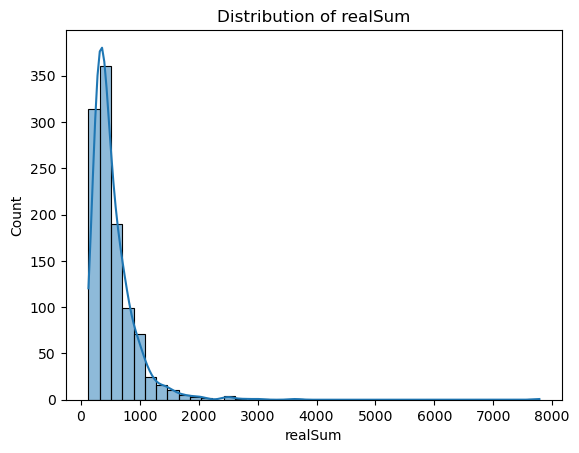

In [28]:
sns.histplot(
    data=df_AMS_weekdays_drop1,
    x="realSum",
    kde=True,
    bins=40
)

plt.title("Distribution of realSum")
plt.show()

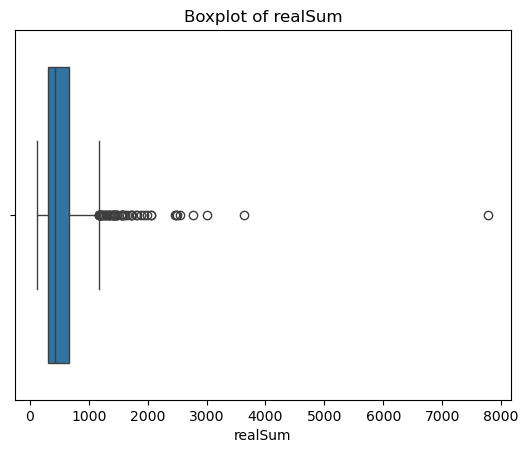

In [30]:
sns.boxplot(
    data=df_AMS_weekdays_drop1,
    x="realSum"
)

plt.title("Boxplot of realSum")
plt.show()

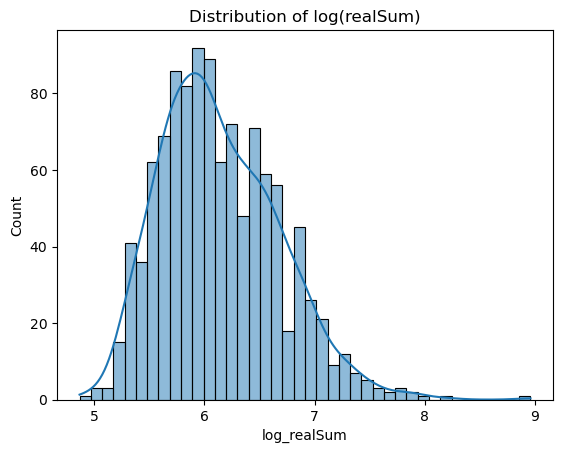

In [32]:
df_AMS_weekdays_drop1["log_realSum"] = np.log1p(df_AMS_weekdays_drop1["realSum"])

sns.histplot(
    data=df_AMS_weekdays_drop1,
    x="log_realSum",
    kde=True,
    bins=40
)

plt.title("Distribution of log(realSum)")
plt.show()

In [34]:
continuous_cols = [
    "dist",
    "metro_dist",
    "attr_index",
    "rest_index",
    "cleanliness_rating",
    "guest_satisfaction_overall"
]

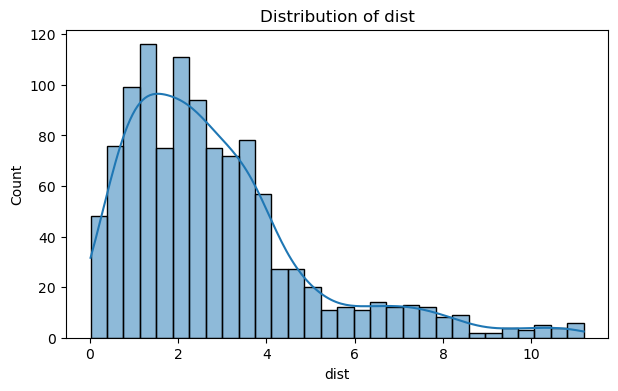

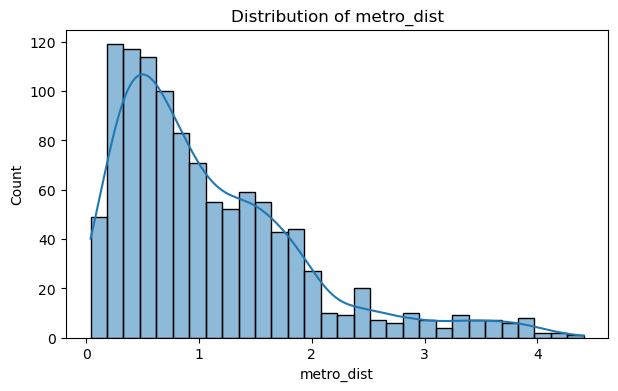

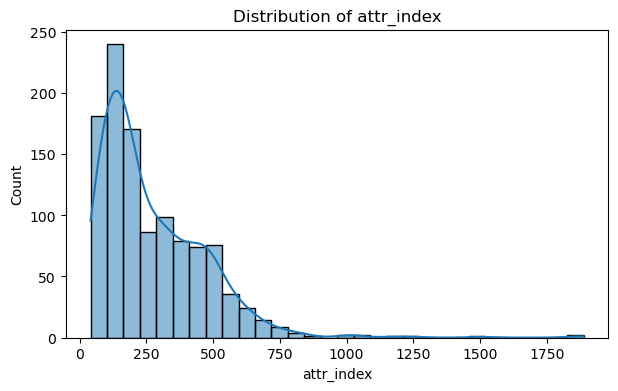

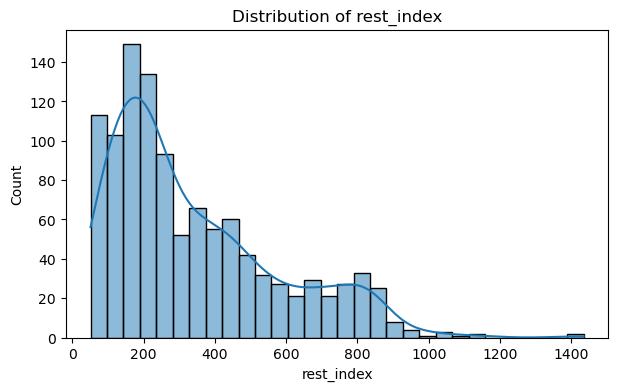

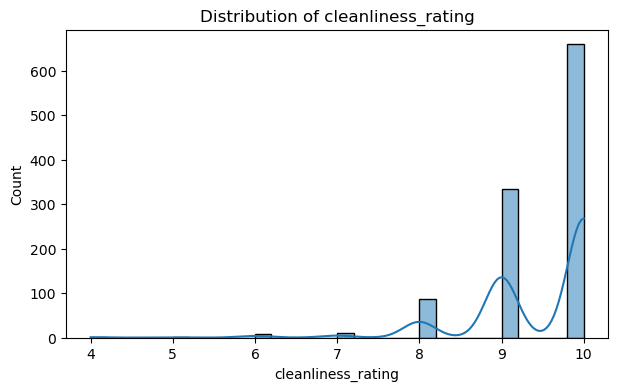

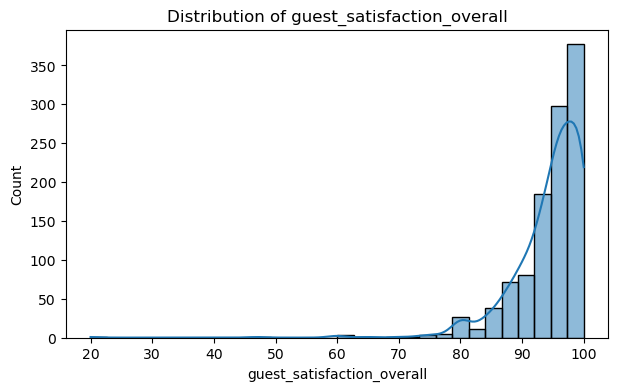

In [36]:
for col in continuous_cols:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df_AMS_weekdays_drop1,
        x=col,
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {col}")
    plt.show()

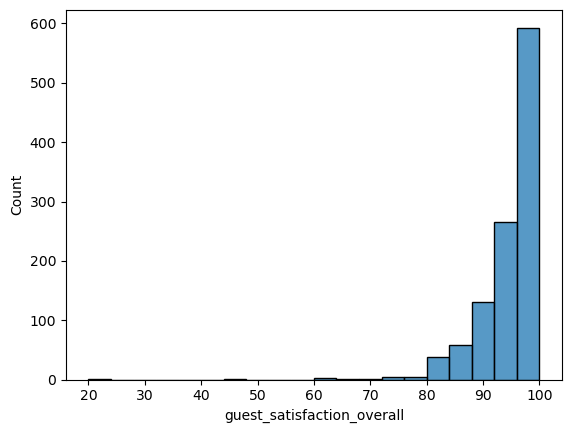

In [40]:
sns.histplot(
    data=df_AMS_weekdays_drop1,
    x="guest_satisfaction_overall",
    bins=20
)

plt.show()

In [42]:
discrete_cols = [
    "person_capacity",
    "bedrooms"
]

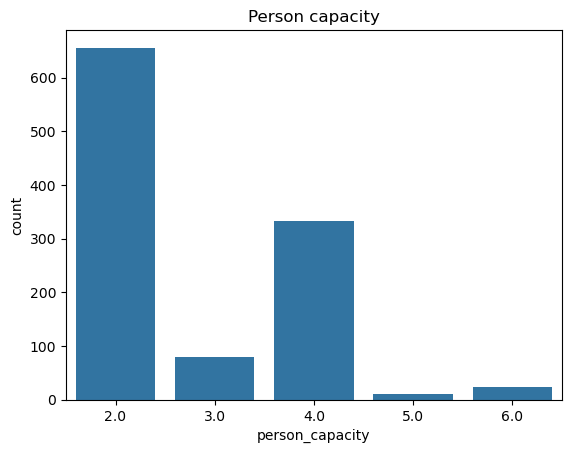

In [46]:
sns.countplot(
    data=df_AMS_weekdays_drop1,
    x="person_capacity"
)

plt.title("Person capacity")
plt.show()

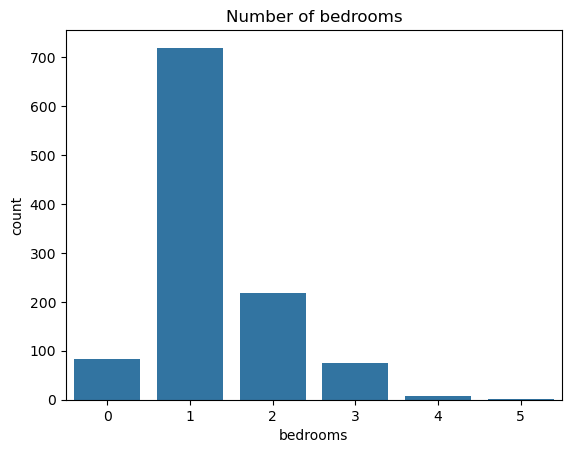

In [48]:
sns.countplot(
    data=df_AMS_weekdays_drop1,
    x="bedrooms"
)

plt.title("Number of bedrooms")
plt.show()

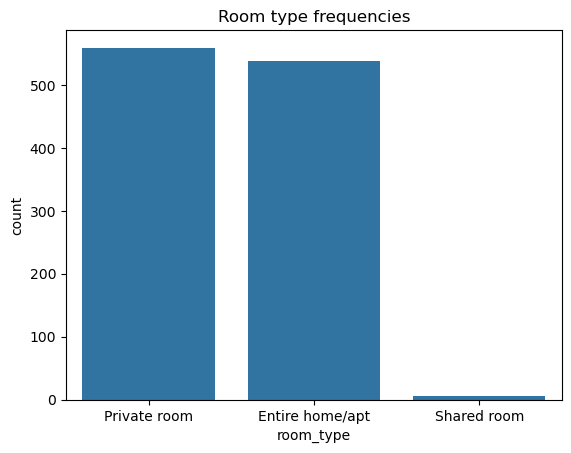

In [50]:
sns.countplot(
    data=df_AMS_weekdays_drop1,
    x="room_type"
)

plt.title("Room type frequencies")
plt.show()

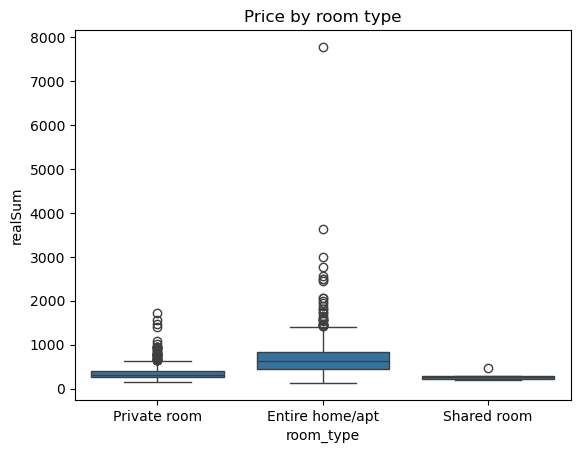

In [52]:
sns.boxplot(
    data=df_AMS_weekdays_drop1,
    x="room_type",
    y="realSum"
)

plt.title("Price by room type")
plt.show()

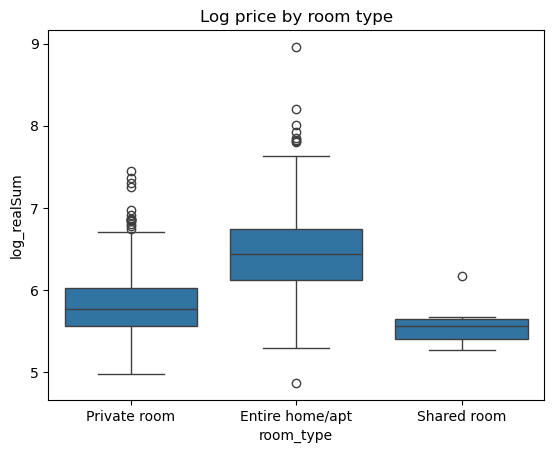

In [54]:
sns.boxplot(
    data=df_AMS_weekdays_drop1,
    x="room_type",
    y="log_realSum"
)

plt.title("Log price by room type")
plt.show()

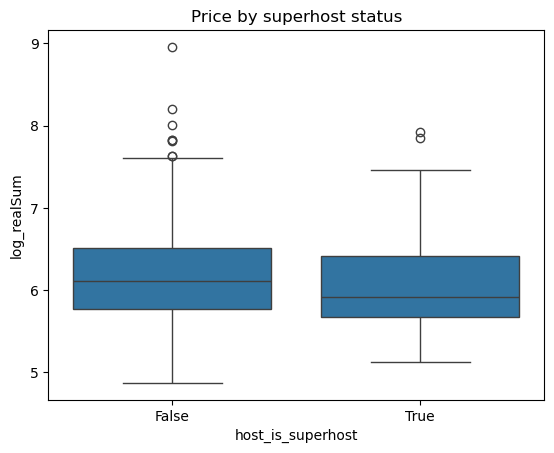

In [56]:
sns.boxplot(
    data=df_AMS_weekdays_drop1,
    x="host_is_superhost",
    y="log_realSum"
)

plt.title("Price by superhost status")
plt.show()

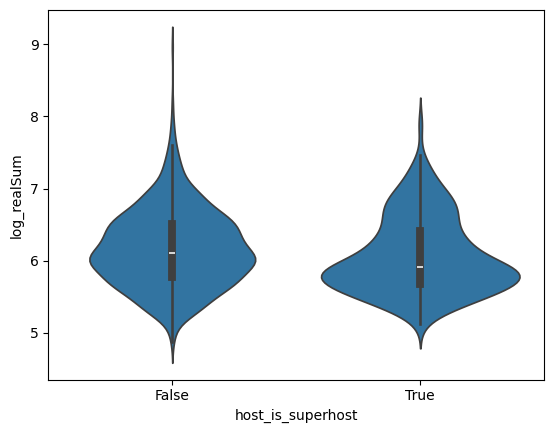

In [58]:
sns.violinplot(
    data=df_AMS_weekdays_drop1,
    x="host_is_superhost",
    y="log_realSum"
)

plt.show()

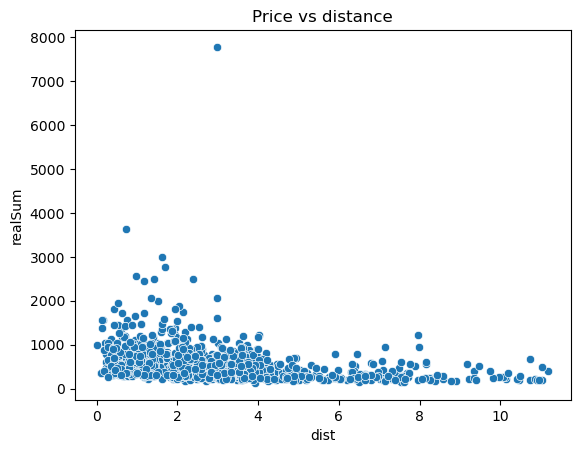

In [60]:
sns.scatterplot(
    data=df_AMS_weekdays_drop1,
    x="dist",
    y="realSum"
)

plt.title("Price vs distance")
plt.show()

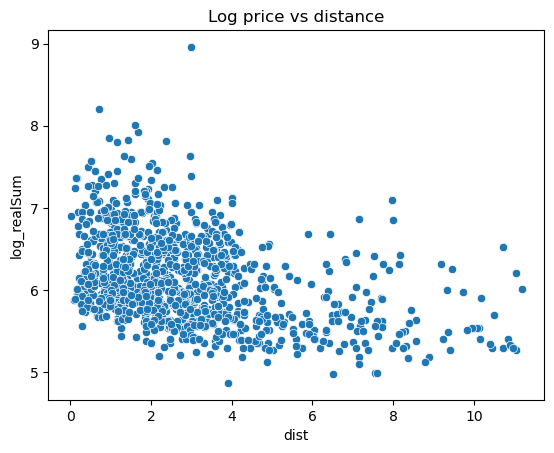

In [62]:
sns.scatterplot(
    data=df_AMS_weekdays_drop1,
    x="dist",
    y="log_realSum"
)

plt.title("Log price vs distance")
plt.show()

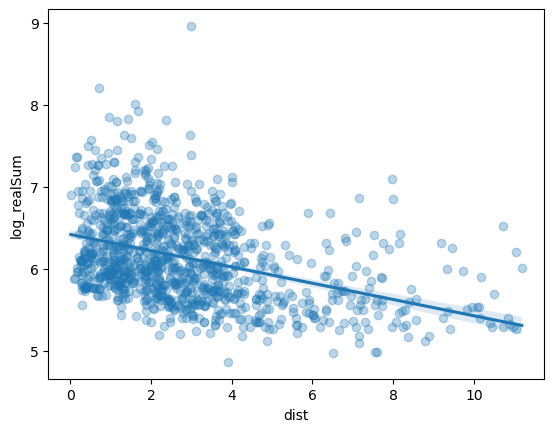

In [64]:
sns.regplot(
    data=df_AMS_weekdays_drop1,
    x="dist",
    y="log_realSum",
    scatter_kws={"alpha": 0.3}
)

plt.show()

In [66]:
#If the scatter plot is approximately linear:

df_AMS_weekdays_drop1[["realSum", "dist"]].corr(method="pearson")

,realSum,dist
realSum,1.000000,-0.258692
dist,-0.258692,1.000000


In [70]:
#If it is monotonic but nonlinear or contains influential outliers:

df_AMS_weekdays_drop1[["realSum", "dist"]].corr(method="spearman")

,realSum,dist
realSum,1.000000,-0.389795
dist,-0.389795,1.000000


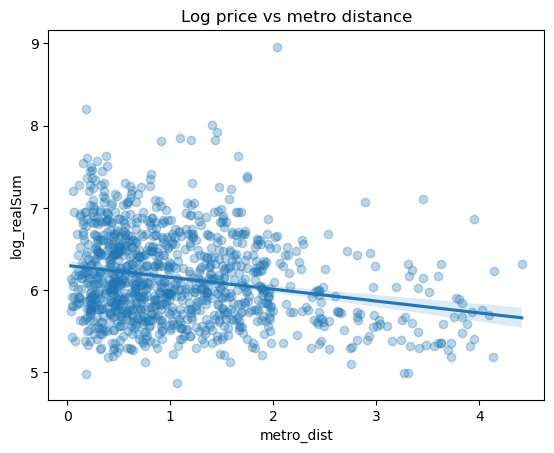

In [72]:
sns.regplot(
    data=df_AMS_weekdays_drop1,
    x="metro_dist",
    y="log_realSum",
    scatter_kws={"alpha": 0.3}
)

plt.title("Log price vs metro distance")
plt.show()

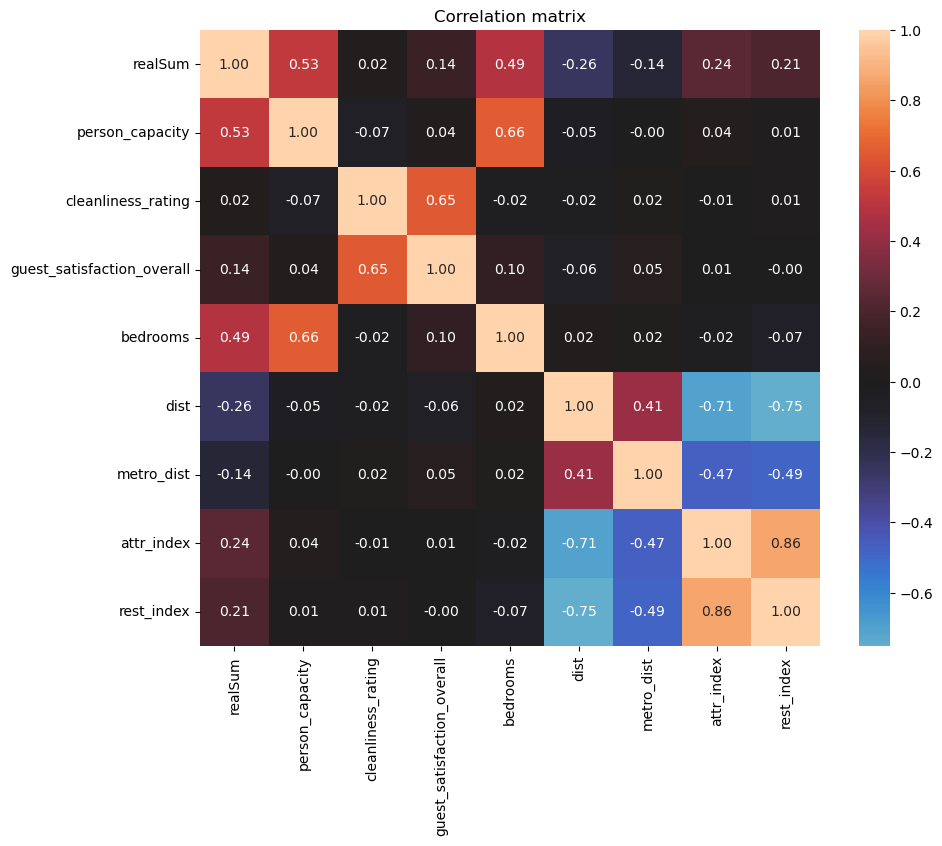

In [74]:
numeric_cols = [
    "realSum",
    "person_capacity",
    "cleanliness_rating",
    "guest_satisfaction_overall",
    "bedrooms",
    "dist",
    "metro_dist",
    "attr_index",
    "rest_index"
]

corr = df_AMS_weekdays_drop1[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation matrix")
plt.show()

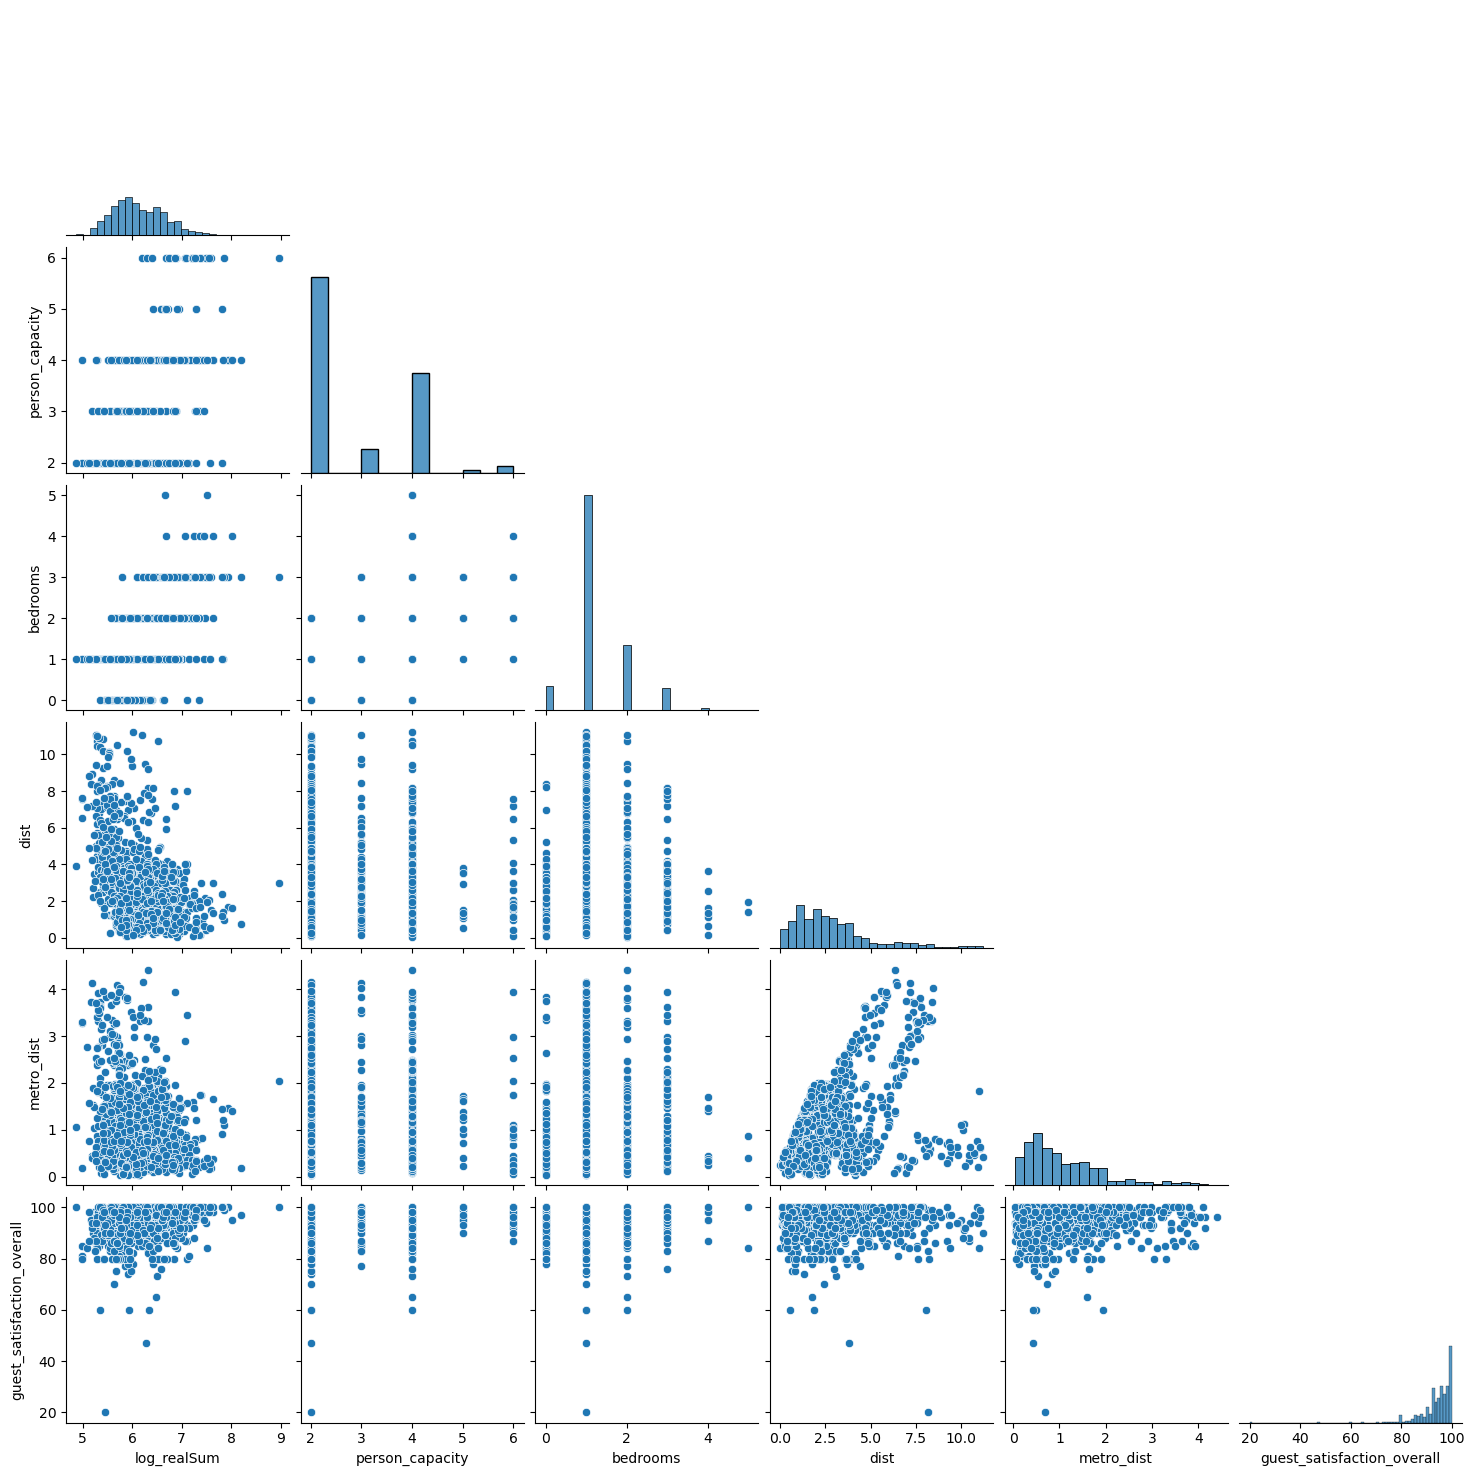

In [76]:
selected = [
    "log_realSum",
    "person_capacity",
    "bedrooms",
    "dist",
    "metro_dist",
    "guest_satisfaction_overall"
]

sns.pairplot(
    df_AMS_weekdays_drop1[selected],
    corner=True
)

plt.show()

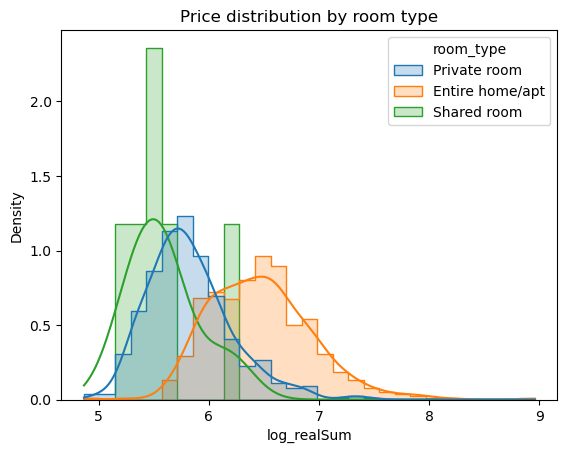

In [78]:
sns.histplot(
    data=df_AMS_weekdays_drop1,
    x="log_realSum",
    hue="room_type",
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Price distribution by room type")
plt.show()

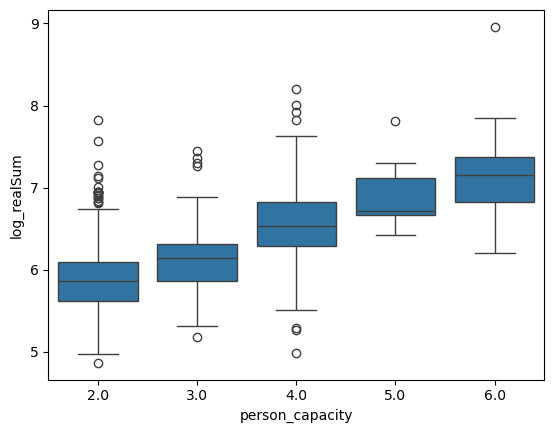

In [80]:
sns.boxplot(
    data=df_AMS_weekdays_drop1,
    x="person_capacity",
    y="log_realSum"
)

plt.show()

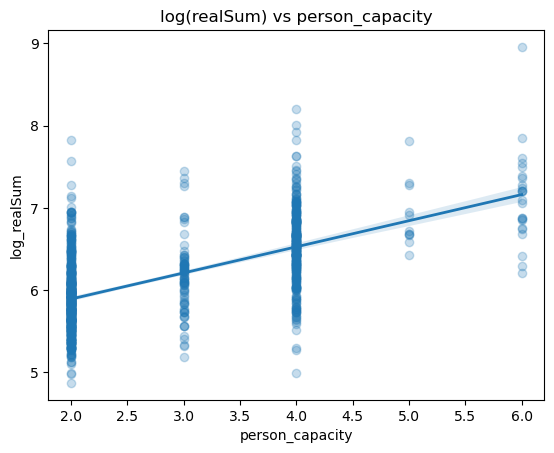

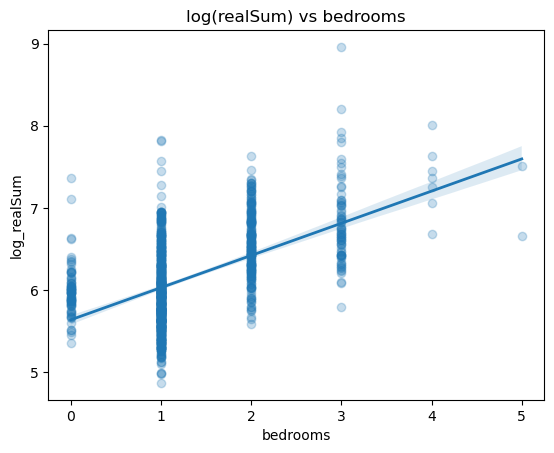

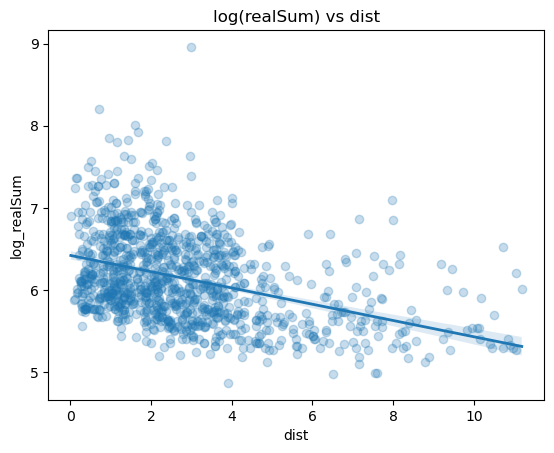

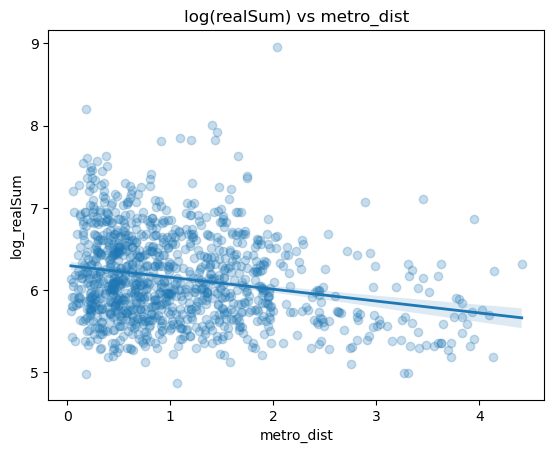

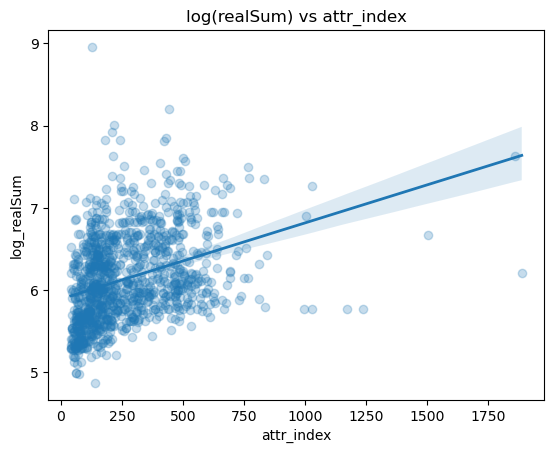

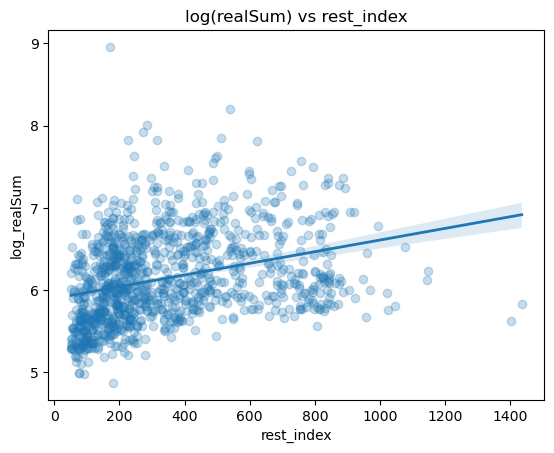

In [82]:
variables = [
    "person_capacity",
    "bedrooms",
    "dist",
    "metro_dist",
    "attr_index",
    "rest_index"
]

for col in variables:

    sns.regplot(
        data=df_AMS_weekdays_drop1,
        x=col,
        y="log_realSum",
        scatter_kws={"alpha": 0.25},
        line_kws={"linewidth": 2}
    )

    plt.title(f"log(realSum) vs {col}")
    plt.show()

## Variance is increasing with capacity.

That indicates heteroskedasticity.

In [85]:
import statsmodels.formula.api as smf

model = smf.ols(
    """
    log_realSum ~
    person_capacity +
    bedrooms +
    dist +
    metro_dist +
    attr_index_norm +
    rest_index_norm +
    guest_satisfaction_overall +
    host_is_superhost +
    C(room_type)
    """,
    data=df_AMS_weekdays_drop1
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_realSum   R-squared:                       0.690
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     243.6
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          7.31e-270
Time:                        15:15:44   Log-Likelihood:                -232.76
No. Observations:                1103   AIC:                             487.5
Df Residuals:                    1092   BIC:                             542.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       